# TAHAP 04 — Intent Classification Modeling

## Tujuan:
Notebook ini bertujuan untuk membangun model klasifikasi intent chatbot EduPath menggunakan dataset hasil preprocessing pada tahap sebelumnya.

Model yang digunakan:
1. Multinomial Naive Bayes
2. Logistic Regression
3. LinearSVC

Tahapan utama:
1. Load dataset processed
2. Audit distribusi label intent
3. Split data train-test
4. Feature extraction menggunakan TF-IDF
5. Training beberapa model baseline
6. Evaluasi model
7. Perbandingan performa model
8. Pemilihan model terbaik
9. Simpan model dan vectorizer
10. Membuat fungsi prediksi intent dari input teks baru

In [1]:
# ============================================================
# TAHAP 04 - Intent Classification Modeling
# Setup Library dan Project Root
# ============================================================

from pathlib import Path
import os
import re
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Logic PROJECT_ROOT
# Notebook dijalankan dari folder notebooks/
# Maka root project adalah parent dari folder notebooks
# ------------------------------------------------------------

def find_project_root(start_path=None):
    """
    Mencari root project secara aman.
    Jika notebook dijalankan dari folder notebooks,
    maka root project adalah parent folder notebooks.
    """
    current_path = Path(start_path or Path.cwd()).resolve()
    
    # Cek ke atas sampai menemukan folder data/processed
    for path in [current_path] + list(current_path.parents):
        if (path / "data" / "processed").exists():
            return path
    
    # Fallback jika sedang berada di folder notebooks
    if current_path.name.lower() == "notebooks":
        return current_path.parent
    
    return current_path

PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_MODELING_DIR = PROJECT_ROOT / "reports" / "modeling"
MODEL_DIR = PROJECT_ROOT / "models"

REPORT_MODELING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT        :", PROJECT_ROOT)
print("DATA_PROCESSED_DIR  :", DATA_PROCESSED_DIR)
print("REPORT_MODELING_DIR :", REPORT_MODELING_DIR)
print("MODEL_DIR           :", MODEL_DIR)

PROJECT_ROOT        : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant
DATA_PROCESSED_DIR  : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\processed
REPORT_MODELING_DIR : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling
MODEL_DIR           : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\models


## 1. Load Dataset Intent Processed

Dataset yang digunakan adalah hasil dari Tahap 03, yaitu:

`data/processed/intent_dataset_processed.csv`

Kolom fitur utama:
- `utterance_preprocessed`

Kolom target:
- `intent_label`

In [2]:
# ============================================================
# Load Dataset Intent Processed
# ============================================================

intent_path = DATA_PROCESSED_DIR / "intent_dataset_processed.csv"

if not intent_path.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {intent_path}")

intent_df = pd.read_csv(intent_path)

print("Shape dataset intent:", intent_df.shape)
print("\nDaftar kolom:")
display(pd.DataFrame({"columns": intent_df.columns}))

display(intent_df.head())

Shape dataset intent: (12, 21)

Daftar kolom:


,columns
0,utterance_id
1,utterance
2,intent_label
3,bahasa
4,register
5,jenjang_user
6,kelas
7,minat_keywords
8,mapel_favorit
9,hobi_keywords


,utterance_id,utterance,intent_label,bahasa,register,jenjang_user,kelas,minat_keywords,mapel_favorit,hobi_keywords,...,tujuan_karier_keywords,target_program_id,source_type,confidence_label,catatan,utterance_clean,utterance_normalized,utterance_tokens,utterance_preprocessed,utterance_token_count
0,UTT001,Saya suka matematika dan ingin bekerja di bida...,rekomendasi_prodi,id_formal,formal,SMA,12,matematika|data|analisis,Matematika|Informatika,membuat grafik|menganalisis data,...,data analyst,PRG003,seed_manual,0.95,Contoh formal,saya suka matematika dan ingin bekerja di bida...,saya suka matematika dan ingin bekerja di bida...,"[""saya"", ""suka"", ""matematika"", ""dan"", ""ingin"",...",suka matematika kerja bidang data program stud...,8
1,UTT002,"Aku seneng ngoding sama statistik, cocoknya ku...",rekomendasi_prodi,id_nonformal,nonformal,SMK,12,coding|statistik,Matematika|Produktif RPL,ngoding|eksperimen aplikasi,...,programmer|data scientist,PRG001,seed_manual,0.90,Contoh non-formal,aku seneng ngoding sama statistik cocoknya kul...,saya suka pemrograman sama statistik cocoknya ...,"[""saya"", ""suka"", ""pemrograman"", ""sama"", ""stati...",suka pemrograman statistik kuliah,4
2,UTT003,"Aku pengin dadi analis data, jurusan sing pas ...",rekomendasi_prodi,jawa_umum,nonformal,SMA,12,data|analisis,Matematika,olah data,...,data analyst,PRG003,seed_manual,0.85,Contoh Jawa umum,aku pengin dadi analis data jurusan sing pas apa,saya ingin menjadi analis data program studi y...,"[""saya"", ""ingin"", ""menjadi"", ""analis"", ""data"",...",jadi analis data program studi,5
3,UTT004,"Abdi resep komputer jeung angka, prodi naon nu...",rekomendasi_prodi,sunda_umum,nonformal,SMA,12,komputer|angka,Matematika|Informatika,komputer,...,software engineer|data analyst,PRG001,seed_manual,0.85,Contoh Sunda umum,abdi resep komputer jeung angka prodi naon nu ...,abdi suka komputer jeung angka prodi apa nu cocog,"[""abdi"", ""suka"", ""komputer"", ""jeung"", ""angka"",...",abdi suka komputer angka prodi cocog,6
4,UTT005,"Kalau ingin masuk Teknik Informatika, saya har...",roadmap_belajar,id_formal,formal,SMA,12,informatika|pemrograman,Informatika,ngoding,...,software engineer,PRG001,seed_manual,0.95,Pertanyaan roadmap,kalau ingin masuk teknik informatika saya haru...,kalau ingin masuk teknik informatika saya haru...,"[""kalau"", ""ingin"", ""masuk"", ""teknik"", ""informa...",masuk teknik informatika ajar,4


## 2. Validasi Kolom Utama

Pada tahap modeling, kita membutuhkan dua kolom utama:

1. `utterance_preprocessed` sebagai fitur teks
2. `intent_label` sebagai target klasifikasi

Jika kolom tersebut tidak tersedia, maka proses modeling tidak dapat dilanjutkan.

In [3]:
# ============================================================
# Validasi Kolom Utama
# ============================================================

required_columns = ["utterance_preprocessed", "intent_label"]

missing_columns = [col for col in required_columns if col not in intent_df.columns]

if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_columns}")

# Ambil kolom yang dibutuhkan untuk modeling
model_df = intent_df.copy()

# Bersihkan data kosong pada fitur dan target
model_df = model_df.dropna(subset=["utterance_preprocessed", "intent_label"])
model_df = model_df[
    model_df["utterance_preprocessed"].astype(str).str.strip().ne("")
].copy()

print("Jumlah data setelah validasi:", model_df.shape[0])
print("Jumlah intent unik:", model_df["intent_label"].nunique())

display(model_df[["utterance", "utterance_preprocessed", "intent_label"]].head())

Jumlah data setelah validasi: 12
Jumlah intent unik: 8


,utterance,utterance_preprocessed,intent_label
0,Saya suka matematika dan ingin bekerja di bida...,suka matematika kerja bidang data program stud...,rekomendasi_prodi
1,"Aku seneng ngoding sama statistik, cocoknya ku...",suka pemrograman statistik kuliah,rekomendasi_prodi
2,"Aku pengin dadi analis data, jurusan sing pas ...",jadi analis data program studi,rekomendasi_prodi
3,"Abdi resep komputer jeung angka, prodi naon nu...",abdi suka komputer angka prodi cocog,rekomendasi_prodi
4,"Kalau ingin masuk Teknik Informatika, saya har...",masuk teknik informatika ajar,roadmap_belajar


## 3. Audit Distribusi Label Intent

Audit distribusi label dilakukan untuk melihat keseimbangan data antar intent.

Hal yang perlu diperhatikan:
- Jika ada label dengan jumlah data sangat kecil, evaluasi model menjadi kurang stabil.
- Jika ada label hanya memiliki 1 data, stratified split tidak dapat dilakukan secara normal.
- Pada dataset kecil, hasil model belum dapat dianggap final.

In [4]:
# ============================================================
# Audit Distribusi Label Intent
# ============================================================

label_distribution = (
    model_df["intent_label"]
    .value_counts()
    .reset_index()
)

label_distribution.columns = ["intent_label", "count"]
label_distribution["percentage"] = (
    label_distribution["count"] / label_distribution["count"].sum() * 100
).round(2)

display(label_distribution)

# Simpan distribusi label ke reports/modeling
label_distribution_path = REPORT_MODELING_DIR / "intent_label_distribution.csv"
label_distribution.to_csv(label_distribution_path, index=False)

print(f"Distribusi label disimpan ke: {label_distribution_path}")

,intent_label,count,percentage
0,rekomendasi_prodi,4,33.33
1,roadmap_belajar,2,16.67
2,prospek_karier,1,8.33
3,skill_awal,1,8.33
4,info_program_studi,1,8.33
5,sapaan,1,8.33
6,klarifikasi_minat,1,8.33
7,fallback,1,8.33


Distribusi label disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\intent_label_distribution.csv


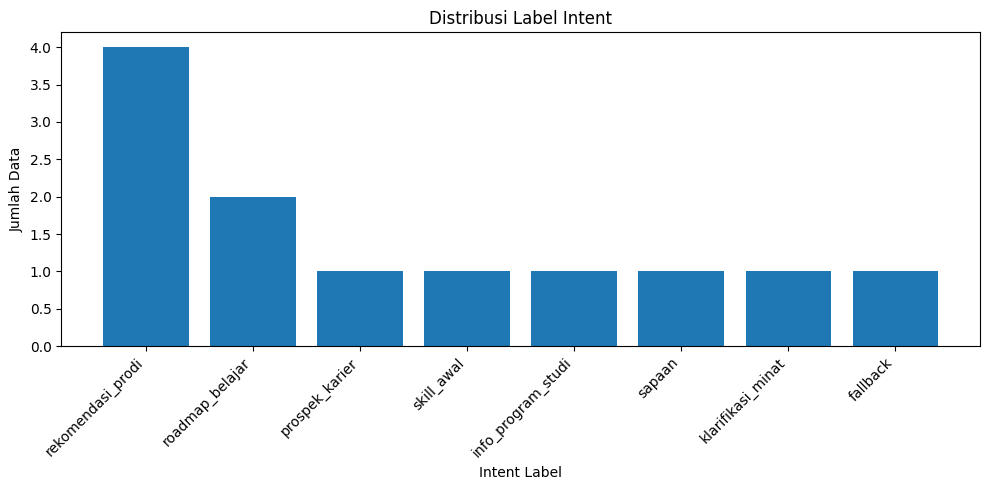

Visualisasi distribusi label disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\intent_label_distribution.png


In [5]:
# ============================================================
# Visualisasi Distribusi Label Intent
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(label_distribution["intent_label"], label_distribution["count"])
plt.title("Distribusi Label Intent")
plt.xlabel("Intent Label")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

label_dist_fig_path = REPORT_MODELING_DIR / "intent_label_distribution.png"
plt.savefig(label_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Visualisasi distribusi label disimpan ke: {label_dist_fig_path}")

## 4. Split Data Train-Test

Dataset akan dibagi menjadi data training dan data testing.

Namun, karena beberapa intent hanya memiliki 1 data, stratified split biasa dapat gagal. Oleh karena itu, digunakan fungsi split yang lebih aman:

- Label dengan jumlah data minimal 2 dapat ikut proses train-test split.
- Label dengan jumlah data hanya 1 dimasukkan ke data training agar model tetap mengenali label tersebut.
- Evaluasi pada data testing tetap dilakukan terhadap label yang tersedia di test set.

Catatan:
Pada dataset kecil, hasil evaluasi hanya digunakan sebagai baseline awal, bukan kesimpulan final.

In [6]:
# ============================================================
# Safe Train-Test Split untuk Dataset Kecil dan Tidak Seimbang
# ============================================================

def safe_train_test_split(
    df,
    target_col="intent_label",
    test_size=0.2,
    random_state=42
):
    """
    Fungsi split data yang aman untuk dataset kecil.
    
    Jika terdapat label dengan jumlah data hanya 1,
    data tersebut dimasukkan ke training set agar model tetap belajar label tersebut.
    """
    
    label_counts = df[target_col].value_counts()
    
    singleton_labels = label_counts[label_counts < 2].index.tolist()
    regular_labels = label_counts[label_counts >= 2].index.tolist()
    
    singleton_df = df[df[target_col].isin(singleton_labels)].copy()
    regular_df = df[df[target_col].isin(regular_labels)].copy()
    
    print("Label dengan data hanya 1:", singleton_labels)
    print("Label dengan data >= 2   :", regular_labels)
    
    if regular_df[target_col].nunique() >= 2:
        n_classes = regular_df[target_col].nunique()
        n_regular = len(regular_df)
        
        # Jumlah test minimal sama dengan jumlah kelas agar stratify aman
        n_test = max(n_classes, int(round(test_size * n_regular)))
        
        # Pastikan train juga masih punya minimal satu data per kelas
        n_test = min(n_test, n_regular - n_classes)
        
        train_regular, test_df = train_test_split(
            regular_df,
            test_size=n_test,
            random_state=random_state,
            stratify=regular_df[target_col]
        )
        
        train_df = pd.concat([train_regular, singleton_df], ignore_index=True)
        train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)
        
    else:
        # Fallback jika dataset terlalu kecil untuk stratified split
        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            random_state=random_state,
            stratify=None
        )
    
    return train_df, test_df


train_df, test_df = safe_train_test_split(
    model_df,
    target_col="intent_label",
    test_size=0.2,
    random_state=42
)

print("Jumlah data train:", train_df.shape[0])
print("Jumlah data test :", test_df.shape[0])

print("\nDistribusi train:")
display(train_df["intent_label"].value_counts().reset_index())

print("\nDistribusi test:")
display(test_df["intent_label"].value_counts().reset_index())

Label dengan data hanya 1: ['prospek_karier', 'skill_awal', 'info_program_studi', 'sapaan', 'klarifikasi_minat', 'fallback']
Label dengan data >= 2   : ['rekomendasi_prodi', 'roadmap_belajar']
Jumlah data train: 10
Jumlah data test : 2

Distribusi train:


,intent_label,count
0,rekomendasi_prodi,3
1,klarifikasi_minat,1
2,skill_awal,1
3,sapaan,1
4,fallback,1
5,prospek_karier,1
6,roadmap_belajar,1
7,info_program_studi,1



Distribusi test:


,intent_label,count
0,roadmap_belajar,1
1,rekomendasi_prodi,1


In [7]:
# ============================================================
# Simpan Ringkasan Train-Test Split
# ============================================================

split_summary = pd.DataFrame({
    "dataset_part": ["train", "test", "total"],
    "rows": [len(train_df), len(test_df), len(model_df)],
    "unique_intent": [
        train_df["intent_label"].nunique(),
        test_df["intent_label"].nunique(),
        model_df["intent_label"].nunique()
    ]
})

display(split_summary)

split_summary_path = REPORT_MODELING_DIR / "train_test_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False)

train_df.to_csv(REPORT_MODELING_DIR / "train_data_stage04.csv", index=False)
test_df.to_csv(REPORT_MODELING_DIR / "test_data_stage04.csv", index=False)

print(f"Ringkasan split disimpan ke: {split_summary_path}")

,dataset_part,rows,unique_intent
0,train,10,8
1,test,2,2
2,total,12,8


Ringkasan split disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\train_test_split_summary.csv


## 5. Feature Extraction Menggunakan TF-IDF

TF-IDF digunakan untuk mengubah teks menjadi representasi numerik.

TF-IDF memperhatikan:
- seberapa sering sebuah kata muncul dalam dokumen,
- seberapa unik kata tersebut dibandingkan dokumen lain.

Pada tahap ini digunakan kombinasi unigram dan bigram agar model dapat menangkap kata tunggal dan frasa pendek.

In [8]:
# ============================================================
# TF-IDF Feature Extraction
# ============================================================

TEXT_COL = "utterance_preprocessed"
TARGET_COL = "intent_label"

X_train_text = train_df[TEXT_COL].astype(str)
X_test_text = test_df[TEXT_COL].astype(str)

y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Shape X_train_tfidf:", X_train_tfidf.shape)
print("Shape X_test_tfidf :", X_test_tfidf.shape)
print("Jumlah fitur TF-IDF:", len(tfidf_vectorizer.get_feature_names_out()))

Shape X_train_tfidf: (10, 80)
Shape X_test_tfidf : (2, 80)
Jumlah fitur TF-IDF: 80


In [9]:
# ============================================================
# Melihat Contoh Fitur TF-IDF
# ============================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Contoh 30 fitur TF-IDF:")
print(feature_names[:30])

Contoh 30 fitur TF-IDF:
['abdi' 'abdi suka' 'ajar' 'ajar lama' 'analyst' 'angka' 'angka prodi'
 'asdf' 'asdf program' 'awal' 'awal data' 'awan' 'awan biru' 'bantu'
 'bantu roadmap' 'beda' 'beda teknik' 'biasa' 'biasa kerja' 'bidang'
 'bidang data' 'bingung' 'bingung tahu' 'biru' 'biru kerja' 'bulan'
 'bulan sains' 'cocog' 'cocok' 'data']


## 6. Training Model Baseline

Pada tahap ini digunakan tiga model baseline:

### 1. Multinomial Naive Bayes
Model probabilistik yang sering digunakan untuk klasifikasi teks.

### 2. Logistic Regression
Model linear yang kuat untuk klasifikasi teks berbasis fitur sparse seperti TF-IDF.

### 3. LinearSVC
Model Support Vector Machine linear yang sering memiliki performa baik pada klasifikasi teks.

Ketiga model akan dibandingkan menggunakan metrik:
- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix

In [10]:
# ============================================================
# Definisi Model Baseline
# ============================================================

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

print("Model yang akan dilatih:")
for model_name in models.keys():
    print("-", model_name)

Model yang akan dilatih:
- Multinomial Naive Bayes
- Logistic Regression
- LinearSVC


Training model: Multinomial Naive Bayes
Accuracy           : 0.5000
Precision Weighted : 0.2500
Recall Weighted    : 0.5000
F1 Weighted        : 0.3333
F1 Macro           : 0.3333

Classification Report:
                    precision    recall  f1-score   support

          fallback       0.00      0.00      0.00         0
info_program_studi       0.00      0.00      0.00         0
 klarifikasi_minat       0.00      0.00      0.00         0
    prospek_karier       0.00      0.00      0.00         0
 rekomendasi_prodi       0.50      1.00      0.67         1
   roadmap_belajar       0.00      0.00      0.00         1
            sapaan       0.00      0.00      0.00         0
        skill_awal       0.00      0.00      0.00         0

          accuracy                           0.50         2
         macro avg       0.06      0.12      0.08         2
      weighted avg       0.25      0.50      0.33         2



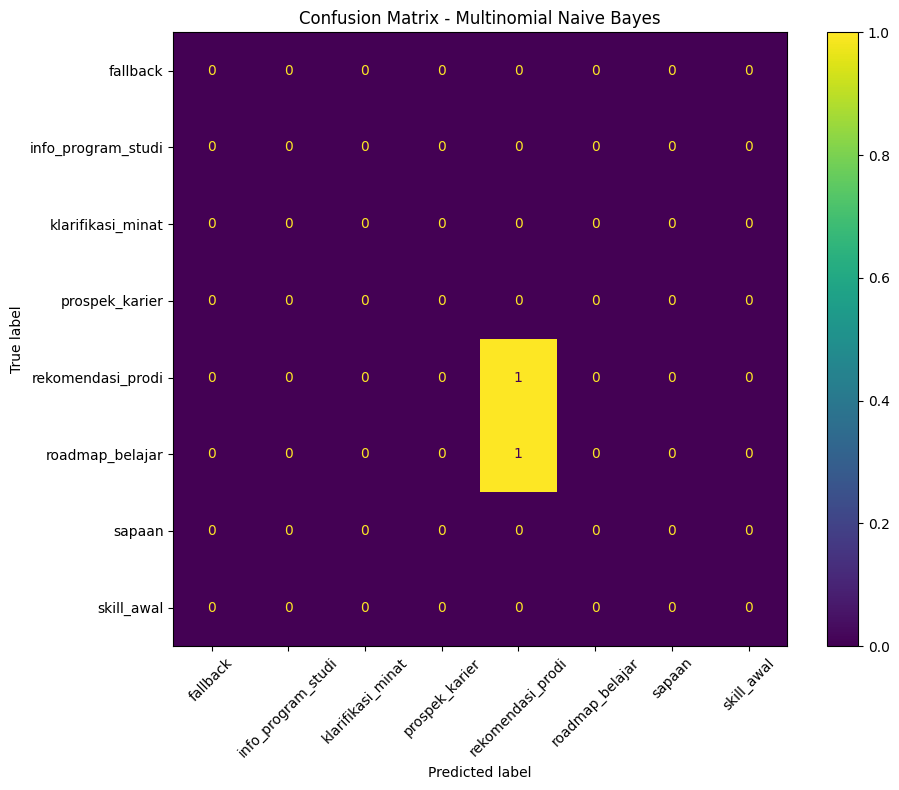

Classification report disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\classification_report_multinomial_naive_bayes.csv
Confusion matrix CSV disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_multinomial_naive_bayes.csv
Confusion matrix PNG disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_multinomial_naive_bayes.png
Training model: Logistic Regression
Accuracy           : 0.0000
Precision Weighted : 0.0000
Recall Weighted    : 0.0000
F1 Weighted        : 0.0000
F1 Macro           : 0.0000

Classification Report:
                    precision    recall  f1-score   support

          fallback       0.00      0.00      0.00       0.0
info_program_studi       0.00      0.00      0.00       0.0
 klarifikasi_minat       0.00      0.00      0.00       0.0
    prospek_karier       0.00

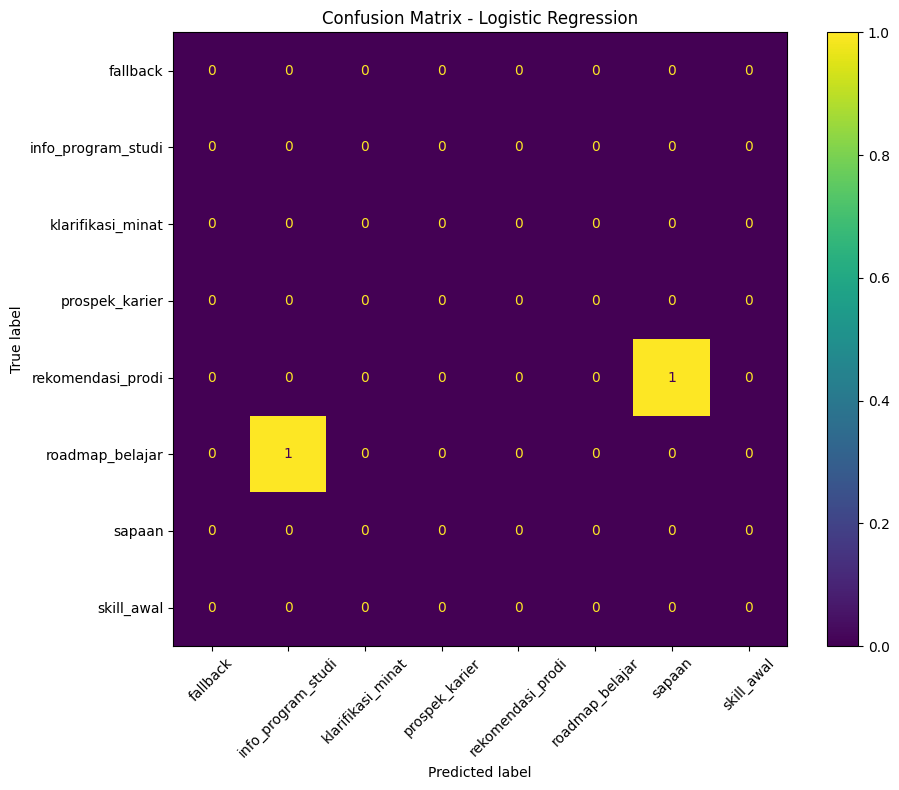

Classification report disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\classification_report_logistic_regression.csv
Confusion matrix CSV disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_logistic_regression.csv
Confusion matrix PNG disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_logistic_regression.png
Training model: LinearSVC
Accuracy           : 0.5000
Precision Weighted : 0.5000
Recall Weighted    : 0.5000
F1 Weighted        : 0.5000
F1 Macro           : 0.3333

Classification Report:
                    precision    recall  f1-score   support

          fallback       0.00      0.00      0.00         0
info_program_studi       0.00      0.00      0.00         0
 klarifikasi_minat       0.00      0.00      0.00         0
    prospek_karier       0.00      0.00      0.00  

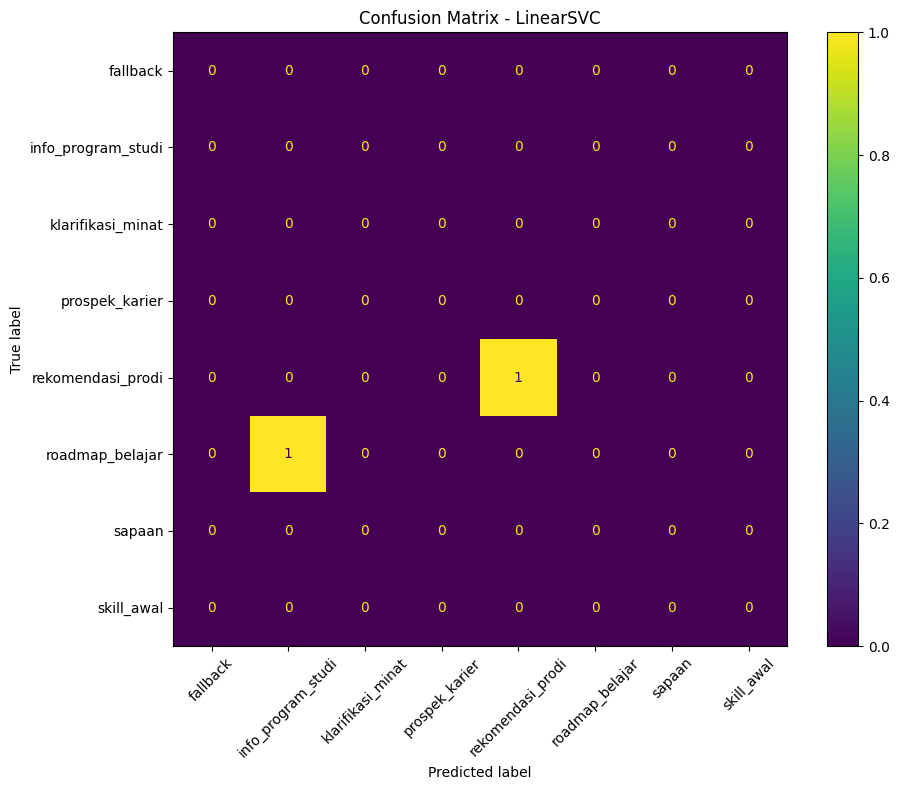

Classification report disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\classification_report_linearsvc.csv
Confusion matrix CSV disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_linearsvc.csv
Confusion matrix PNG disimpan ke : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\confusion_matrix_linearsvc.png


In [11]:
# ============================================================
# Training dan Evaluasi Model
# ============================================================

all_labels = sorted(model_df[TARGET_COL].unique())

evaluation_results = []
trained_models = {}

def slugify(text):
    """
    Membuat nama file aman dari nama model.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = text.strip("_")
    return text

for model_name, model in models.items():
    print("=" * 80)
    print(f"Training model: {model_name}")
    
    # Training
    model.fit(X_train_tfidf, y_train)
    trained_models[model_name] = model
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_weighted = precision_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    recall_weighted = recall_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_weighted = f1_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(
        y_test, y_pred, average="macro", zero_division=0
    )
    
    evaluation_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro
    })
    
    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Precision Weighted : {precision_weighted:.4f}")
    print(f"Recall Weighted    : {recall_weighted:.4f}")
    print(f"F1 Weighted        : {f1_weighted:.4f}")
    print(f"F1 Macro           : {f1_macro:.4f}")
    
    print("\nClassification Report:")
    report_text = classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        zero_division=0
    )
    print(report_text)
    
    # Export classification report
    report_dict = classification_report(
        y_test,
        y_pred,
        labels=all_labels,
        output_dict=True,
        zero_division=0
    )
    
    report_df = pd.DataFrame(report_dict).transpose()
    report_path = REPORT_MODELING_DIR / f"classification_report_{slugify(model_name)}.csv"
    report_df.to_csv(report_path)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    cm_df = pd.DataFrame(cm, index=all_labels, columns=all_labels)
    
    cm_path = REPORT_MODELING_DIR / f"confusion_matrix_{slugify(model_name)}.csv"
    cm_df.to_csv(cm_path)
    
    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    
    cm_fig_path = REPORT_MODELING_DIR / f"confusion_matrix_{slugify(model_name)}.png"
    plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Classification report disimpan ke: {report_path}")
    print(f"Confusion matrix CSV disimpan ke : {cm_path}")
    print(f"Confusion matrix PNG disimpan ke : {cm_fig_path}")

## 7. Perbandingan Performa Model

Model dibandingkan berdasarkan beberapa metrik.

Untuk dataset intent yang tidak seimbang, F1-score lebih penting daripada accuracy karena accuracy dapat terlihat tinggi meskipun model hanya dominan memprediksi kelas mayoritas.

Pada tahap ini, model terbaik dipilih berdasarkan:
1. F1 Macro
2. F1 Weighted
3. Accuracy

In [12]:
# ============================================================
# Perbandingan Performa Model
# ============================================================

comparison_df = pd.DataFrame(evaluation_results)

comparison_df = comparison_df.sort_values(
    by=["f1_macro", "f1_weighted", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

comparison_path = REPORT_MODELING_DIR / "model_comparison_stage04.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"Perbandingan model disimpan ke: {comparison_path}")

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,LinearSVC,0.5,0.50,0.5,0.500000,0.333333
1,Multinomial Naive Bayes,0.5,0.25,0.5,0.333333,0.333333
2,Logistic Regression,0.0,0.00,0.0,0.000000,0.000000


Perbandingan model disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\model_comparison_stage04.csv


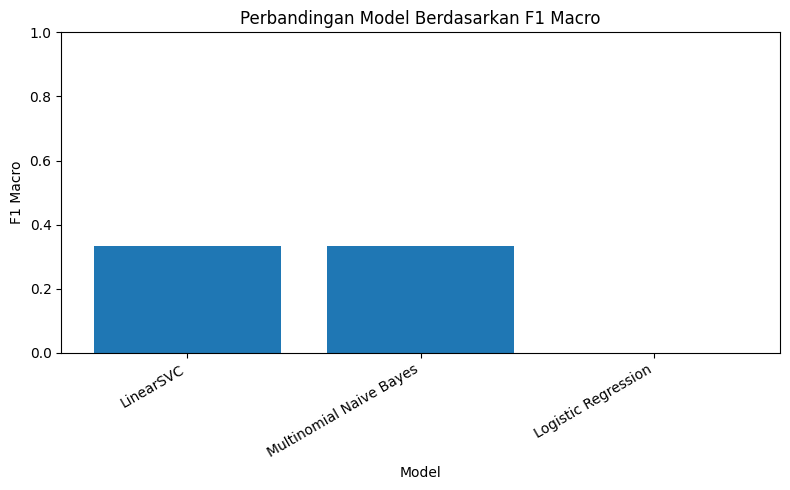

Visualisasi perbandingan model disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\model_comparison_f1_macro.png


In [13]:
# ============================================================
# Visualisasi Perbandingan Model Berdasarkan F1 Macro
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["f1_macro"])
plt.title("Perbandingan Model Berdasarkan F1 Macro")
plt.xlabel("Model")
plt.ylabel("F1 Macro")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

model_comparison_fig_path = REPORT_MODELING_DIR / "model_comparison_f1_macro.png"
plt.savefig(model_comparison_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Visualisasi perbandingan model disimpan ke: {model_comparison_fig_path}")

## 8. Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan nilai F1 Macro tertinggi.

Alasan menggunakan F1 Macro:
- setiap intent dianggap penting,
- tidak terlalu bias terhadap kelas mayoritas,
- cocok untuk dataset intent yang distribusinya belum seimbang.

Namun, karena dataset masih kecil, hasil pemilihan model pada tahap ini bersifat baseline awal.

In [14]:
# ============================================================
# Pemilihan Model Terbaik
# ============================================================

best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Model terbaik berdasarkan F1 Macro:")
print(best_model_name)

display(comparison_df.iloc[[0]])

Model terbaik berdasarkan F1 Macro:
LinearSVC


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,LinearSVC,0.5,0.5,0.5,0.5,0.333333


## 9. Simpan Model dan TF-IDF Vectorizer

Model terbaik dan TF-IDF vectorizer disimpan ke folder:

`models/`

File yang disimpan:
1. `intent_classifier_best_model.joblib`
2. `intent_tfidf_vectorizer.joblib`
3. `intent_classifier_metadata.json`

Metadata disimpan agar informasi model, label, tanggal training, dan metrik evaluasi dapat dilacak kembali.

In [15]:
# ============================================================
# Simpan Model, Vectorizer, dan Metadata
# ============================================================

best_model_path = MODEL_DIR / "intent_classifier_best_model.joblib"
vectorizer_path = MODEL_DIR / "intent_tfidf_vectorizer.joblib"
metadata_path = MODEL_DIR / "intent_classifier_metadata.json"

joblib.dump(best_model, best_model_path)
joblib.dump(tfidf_vectorizer, vectorizer_path)

best_model_metrics = comparison_df.iloc[0].to_dict()

metadata = {
    "project": "EduPath Career Assistant",
    "stage": "Tahap 04 - Intent Classification Modeling",
    "training_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_path": str(intent_path.relative_to(PROJECT_ROOT)),
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "best_model_name": best_model_name,
    "labels": all_labels,
    "metrics": best_model_metrics,
    "notes": (
        "Model ini merupakan baseline awal. "
        "Dataset masih kecil sehingga evaluasi belum dapat dianggap final."
    )
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Model terbaik disimpan ke    :", best_model_path)
print("TF-IDF vectorizer disimpan ke:", vectorizer_path)
print("Metadata disimpan ke         :", metadata_path)

Model terbaik disimpan ke    : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\models\intent_classifier_best_model.joblib
TF-IDF vectorizer disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\models\intent_tfidf_vectorizer.joblib
Metadata disimpan ke         : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\models\intent_classifier_metadata.json


## 10. Preprocessing Input Baru untuk Prediksi Intent

Agar input baru dari user dapat diprediksi, teks mentah perlu diproses terlebih dahulu.

Fungsi berikut melakukan:
1. lowercase
2. hapus karakter non-huruf/angka
3. normalisasi kata non-formal/daerah sederhana
4. stopword removal
5. stemming jika library Sastrawi tersedia

Catatan:
Fungsi ini dibuat agar prediksi input baru tetap konsisten dengan pendekatan preprocessing pada Tahap 03.

In [16]:
# ============================================================
# Fungsi Preprocessing untuk Input Baru
# ============================================================

normalization_path = DATA_PROCESSED_DIR / "normalisasi_bahasa_processed.csv"

def load_normalization_dictionary(path):
    """
    Membuat dictionary normalisasi dari file normalisasi_bahasa_processed.csv.
    """
    if not path.exists():
        print("File normalisasi tidak ditemukan. Normalisasi kata dilewati.")
        return {}
    
    norm_df = pd.read_csv(path)
    
    required_norm_cols = ["kata_input_clean", "kata_baku_clean"]
    if not all(col in norm_df.columns for col in required_norm_cols):
        print("Kolom normalisasi tidak lengkap. Normalisasi kata dilewati.")
        return {}
    
    norm_dict = dict(
        zip(
            norm_df["kata_input_clean"].astype(str),
            norm_df["kata_baku_clean"].astype(str)
        )
    )
    
    return norm_dict

normalization_dict = load_normalization_dictionary(normalization_path)

# Stopwords sederhana tambahan
custom_stopwords = {
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan",
    "saya", "aku", "gue", "ingin", "mau", "apa", "ya",
    "dong", "kak", "min", "nih", "itu", "ini"
}

# Coba gunakan Sastrawi jika tersedia
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    stemmer = StemmerFactory().create_stemmer()
    print("Sastrawi stemmer tersedia.")
except Exception:
    stemmer = None
    print("Sastrawi stemmer tidak tersedia. Stemming dilewati.")

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    sastrawi_stopwords = set(StopWordRemoverFactory().get_stop_words())
    print("Sastrawi stopwords tersedia.")
except Exception:
    sastrawi_stopwords = set()
    print("Sastrawi stopwords tidak tersedia. Menggunakan custom stopwords.")

stopwords = sastrawi_stopwords.union(custom_stopwords)

def preprocess_new_text(text):
    """
    Preprocessing sederhana untuk input teks baru.
    """
    text = str(text).lower()
    
    # Hapus karakter selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    
    # Normalisasi kata
    tokens = [normalization_dict.get(token, token) for token in tokens]
    
    # Stopword removal dan filter token pendek
    tokens = [
        token for token in tokens
        if token not in stopwords and len(token) > 1
    ]
    
    # Stemming jika tersedia
    if stemmer is not None:
        tokens = [stemmer.stem(token) for token in tokens]
    
    return " ".join(tokens)

Sastrawi stemmer tersedia.
Sastrawi stopwords tersedia.


## 11. Fungsi Prediksi Intent dari Input Teks Baru

Fungsi ini digunakan untuk menguji model dengan kalimat baru.

Output fungsi:
- input asli
- input hasil preprocessing
- intent hasil prediksi
- top intent beserta skor jika model mendukung probabilitas atau decision score

In [17]:
# ============================================================
# Fungsi Prediksi Intent
# ============================================================

def predict_intent(text, top_n=3):
    """
    Memprediksi intent dari input teks baru.
    """
    processed_text = preprocess_new_text(text)
    X_new = tfidf_vectorizer.transform([processed_text])
    
    predicted_intent = best_model.predict(X_new)[0]
    
    result = {
        "input_text": text,
        "processed_text": processed_text,
        "predicted_intent": predicted_intent
    }
    
    # Jika model mendukung probabilitas
    if hasattr(best_model, "predict_proba"):
        probabilities = best_model.predict_proba(X_new)[0]
        classes = best_model.classes_
        
        top_indices = np.argsort(probabilities)[::-1][:top_n]
        top_predictions = [
            {
                "intent": classes[i],
                "score": float(probabilities[i])
            }
            for i in top_indices
        ]
        
        result["top_predictions"] = top_predictions
    
    # Jika model tidak punya predict_proba, gunakan decision_function
    elif hasattr(best_model, "decision_function"):
        scores = best_model.decision_function(X_new)
        scores = np.atleast_2d(scores)
        
        classes = best_model.classes_
        raw_scores = scores[0]
        
        # Softmax approximation agar mudah dibaca sebagai skor relatif
        exp_scores = np.exp(raw_scores - np.max(raw_scores))
        relative_scores = exp_scores / exp_scores.sum()
        
        top_indices = np.argsort(relative_scores)[::-1][:top_n]
        top_predictions = [
            {
                "intent": classes[i],
                "score": float(relative_scores[i])
            }
            for i in top_indices
        ]
        
        result["top_predictions"] = top_predictions
    
    return result

In [18]:
# ============================================================
# Uji Prediksi Intent dengan Input Baru
# ============================================================

sample_inputs = [
    "Saya suka matematika dan data, jurusan apa yang cocok?",
    "Kalau mau jadi data analyst harus belajar apa dulu?",
    "Prospek kerja teknik informatika apa saja?",
    "Halo kak, saya mau tanya jurusan kuliah",
    "Saya masih bingung minat saya cocok ke bidang apa"
]

prediction_results = []

for text in sample_inputs:
    pred = predict_intent(text, top_n=3)
    prediction_results.append({
        "input_text": pred["input_text"],
        "processed_text": pred["processed_text"],
        "predicted_intent": pred["predicted_intent"],
        "top_predictions": pred.get("top_predictions", [])
    })

prediction_df = pd.DataFrame(prediction_results)
display(prediction_df)

sample_prediction_path = REPORT_MODELING_DIR / "sample_intent_predictions.csv"
prediction_df.to_csv(sample_prediction_path, index=False)

print(f"Hasil sample prediction disimpan ke: {sample_prediction_path}")

,input_text,processed_text,predicted_intent,top_predictions
0,"Saya suka matematika dan data, jurusan apa yan...",suka matematika data program studi cocok,rekomendasi_prodi,"[{'intent': 'rekomendasi_prodi', 'score': 0.24..."
1,Kalau mau jadi data analyst harus belajar apa ...,kalau jadi data analyst ajar dulu,skill_awal,"[{'intent': 'skill_awal', 'score': 0.218786387..."
2,Prospek kerja teknik informatika apa saja?,prospek kerja teknik informatika,info_program_studi,"[{'intent': 'info_program_studi', 'score': 0.2..."
3,"Halo kak, saya mau tanya jurusan kuliah",halo tanya program studi kuliah,sapaan,"[{'intent': 'sapaan', 'score': 0.2724152911490..."
4,Saya masih bingung minat saya cocok ke bidang apa,bingung minat cocok bidang,klarifikasi_minat,"[{'intent': 'klarifikasi_minat', 'score': 0.20..."


Hasil sample prediction disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\sample_intent_predictions.csv


## 12. Validasi Load Model dari Folder `models/`

Tahap ini memastikan bahwa model dan vectorizer yang sudah disimpan dapat dibuka kembali.

Validasi ini penting karena pada tahap deployment atau integrasi chatbot, model akan dipanggil ulang dari file `.joblib`.

In [19]:
# ============================================================
# Validasi Load Model dan Vectorizer
# ============================================================

loaded_model = joblib.load(best_model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

test_text = "Aku suka ngoding dan statistik, cocok kuliah apa?"
test_processed = preprocess_new_text(test_text)
test_vector = loaded_vectorizer.transform([test_processed])
test_prediction = loaded_model.predict(test_vector)[0]

print("Input asli       :", test_text)
print("Input processed  :", test_processed)
print("Prediksi intent  :", test_prediction)

Input asli       : Aku suka ngoding dan statistik, cocok kuliah apa?
Input processed  : suka pemrograman statistik cocok kuliah
Prediksi intent  : rekomendasi_prodi


## 13. Ringkasan Tahap 04

Pada tahap ini telah dilakukan proses intent classification modeling dengan alur sebagai berikut:

1. Dataset intent hasil preprocessing berhasil dimuat dari `data/processed`.
2. Distribusi label intent berhasil diaudit.
3. Dataset dibagi menjadi train dan test menggunakan safe split.
4. Teks diubah menjadi fitur numerik menggunakan TF-IDF.
5. Tiga model baseline dilatih:
   - Multinomial Naive Bayes
   - Logistic Regression
   - LinearSVC
6. Model dievaluasi menggunakan:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Classification Report
   - Confusion Matrix
7. Model terbaik dipilih berdasarkan F1 Macro.
8. Model terbaik dan TF-IDF vectorizer disimpan ke folder `models/`.
9. Fungsi prediksi intent untuk input baru berhasil dibuat.

Catatan akademik:
Karena dataset intent saat ini masih kecil, hasil performa model belum dapat dijadikan kesimpulan final. Model ini digunakan sebagai baseline awal dan perlu dievaluasi ulang setelah dataset diperbesar.

In [20]:
# ============================================================
# Export Ringkasan Model Terbaik
# ============================================================

summary_text = f"""
TAHAP 04 — Intent Classification Modeling

Project:
EduPath Career Assistant

Dataset:
{intent_path.relative_to(PROJECT_ROOT)}

Jumlah data:
{len(model_df)}

Jumlah intent:
{model_df[TARGET_COL].nunique()}

Model terbaik:
{best_model_name}

Metrik model terbaik:
Accuracy           : {best_model_metrics['accuracy']:.4f}
Precision Weighted : {best_model_metrics['precision_weighted']:.4f}
Recall Weighted    : {best_model_metrics['recall_weighted']:.4f}
F1 Weighted        : {best_model_metrics['f1_weighted']:.4f}
F1 Macro           : {best_model_metrics['f1_macro']:.4f}

Catatan:
Model ini merupakan baseline awal karena dataset masih kecil dan distribusi label belum seimbang.
"""

summary_path = REPORT_MODELING_DIR / "best_model_summary_stage04.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print(f"Ringkasan model terbaik disimpan ke: {summary_path}")


TAHAP 04 — Intent Classification Modeling

Project:
EduPath Career Assistant

Dataset:
data\processed\intent_dataset_processed.csv

Jumlah data:
12

Jumlah intent:
8

Model terbaik:
LinearSVC

Metrik model terbaik:
Accuracy           : 0.5000
Precision Weighted : 0.5000
Recall Weighted    : 0.5000
F1 Weighted        : 0.5000
F1 Macro           : 0.3333

Catatan:
Model ini merupakan baseline awal karena dataset masih kecil dan distribusi label belum seimbang.

Ringkasan model terbaik disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\modeling\best_model_summary_stage04.txt


Pada Tahap 04 dilakukan pemodelan intent classification untuk chatbot EduPath Career Assistant. Dataset yang digunakan adalah dataset intent hasil preprocessing dari Tahap 03. Kolom `utterance_preprocessed` digunakan sebagai fitur teks, sedangkan `intent_label` digunakan sebagai target klasifikasi.

Feature extraction dilakukan menggunakan TF-IDF dengan kombinasi unigram dan bigram. Tiga model baseline diuji, yaitu Multinomial Naive Bayes, Logistic Regression, dan LinearSVC. Evaluasi dilakukan menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix.

Model terbaik dipilih berdasarkan F1 Macro karena metrik ini lebih adil untuk dataset multi-class yang distribusi labelnya belum seimbang. Namun, karena jumlah dataset pada tahap ini masih terbatas, hasil evaluasi belum dapat dianggap sebagai performa final. Model yang dihasilkan digunakan sebagai baseline awal untuk membuktikan bahwa alur intent classification sudah berjalan dan dapat diintegrasikan pada tahap berikutnya.